# 국가별 음주 데이터 분석

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# windows용 한글 폰트 오류 해결
from matplotlib import font_manager, rc
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = font_manager.FontProperties(fname = font_path).get_name()
rc('font', family=font_name)

## 데이터 파악

In [5]:
drinks = pd.read_csv("./data/csv/drinks.csv")

In [6]:
drinks.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0,0,0,0.0,AS
1,Albania,89,132,54,4.9,EU
2,Algeria,25,0,14,0.7,AF
3,Andorra,245,138,312,12.4,EU
4,Angola,217,57,45,5.9,AF


In [7]:
drinks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       193 non-null    object 
 1   beer_servings                 193 non-null    int64  
 2   spirit_servings               193 non-null    int64  
 3   wine_servings                 193 non-null    int64  
 4   total_litres_of_pure_alcohol  193 non-null    float64
 5   continent                     170 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 9.2+ KB


In [8]:
drinks.describe()

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
count,193.000000,193.000000,193.000000,193.000000
mean,106.160622,80.994819,49.450777,4.717098
std,101.143103,88.284312,79.697598,3.773298
min,0.000000,0.000000,0.000000,0.000000
25%,20.000000,4.000000,1.000000,1.300000
50%,76.000000,56.000000,8.000000,4.200000
75%,188.000000,128.000000,59.000000,7.200000
max,376.000000,438.000000,370.000000,14.400000


- 피처
    - country : 국가 정보
    - beer/spirit/wine_servings : beer/spirit/wine 소비량
    - total_litres_of_pure_alcohol : 총 알코올 소비량
    - continent : 국가의 대륙 정보

## 데이터 속성 탐색

- 상관분석
    - 두 변수 간의 선형적 관계를 상관 계수로 표현하는 것
 
    - 상관계수는 공분산의 개념을 포함
        - 공분산
            - 2개의 확률변수에 대한 상관 정도
            - 2개의 변수 중 하나의 값이 상승하는 경향을 보일 때 다른 값도 상승하는 경향을 수치로 나타낸 것
            - 공분산만으로 상관관계를 구한다면 두 변수의 단위 크기에 영향을 받음
                - 큰 단위의 데이터라면 공분산이 커짐
             
    - 따라서 상관계수는 공분산을 -1과 1 사이의 값으로 변환한 것
 
- 상관관계를 통계적으로 탐색하는 방법
    - 단순 상관 분석 : 피처가 2개일 때의 상관계수를 계산
    - 다중 상관 분석 : 피처가 여러 개일 때 상호 간의 연관성 분석

### beer, wine의 상관계수 구하기

In [9]:
drinks[["beer_servings", "wine_servings"]].corr()

,beer_servings,wine_servings
beer_servings,1.000000,0.527172
wine_servings,0.527172,1.000000


### 다중 상관 분석

In [10]:
drinks.corr(numeric_only = True)

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
beer_servings,1.000000,0.458819,0.527172,0.835839
spirit_servings,0.458819,1.000000,0.194797,0.654968
wine_servings,0.527172,0.194797,1.000000,0.667598
total_litres_of_pure_alcohol,0.835839,0.654968,0.667598,1.000000


In [11]:
cor_cols = drinks.columns[1:5]

In [12]:
drinks_corr = drinks[cor_cols].corr()
drinks_corr

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
beer_servings,1.000000,0.458819,0.527172,0.835839
spirit_servings,0.458819,1.000000,0.194797,0.654968
wine_servings,0.527172,0.194797,1.000000,0.667598
total_litres_of_pure_alcohol,0.835839,0.654968,0.667598,1.000000


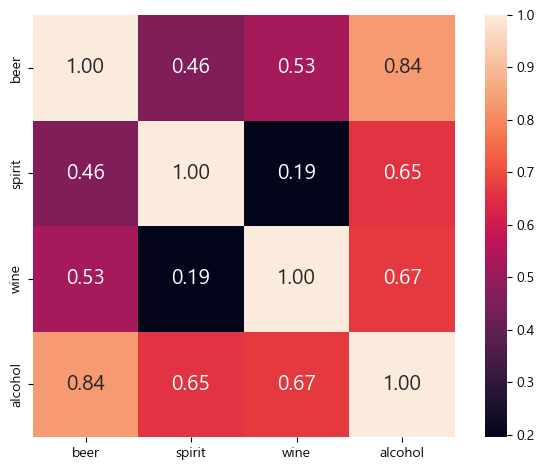

In [13]:
# 그래프 출력을 위해 컬럼명 축약
cols_label = ["beer", "spirit", "wine", "alcohol"]

hm = sns.heatmap(drinks_corr.values, cbar = True, annot = True, square = True, fmt = ".2f", annot_kws = {"size" : 15}, yticklabels = cols_label, xticklabels = cols_label)

plt.tight_layout()

plt.show()

### 산점도 시각화

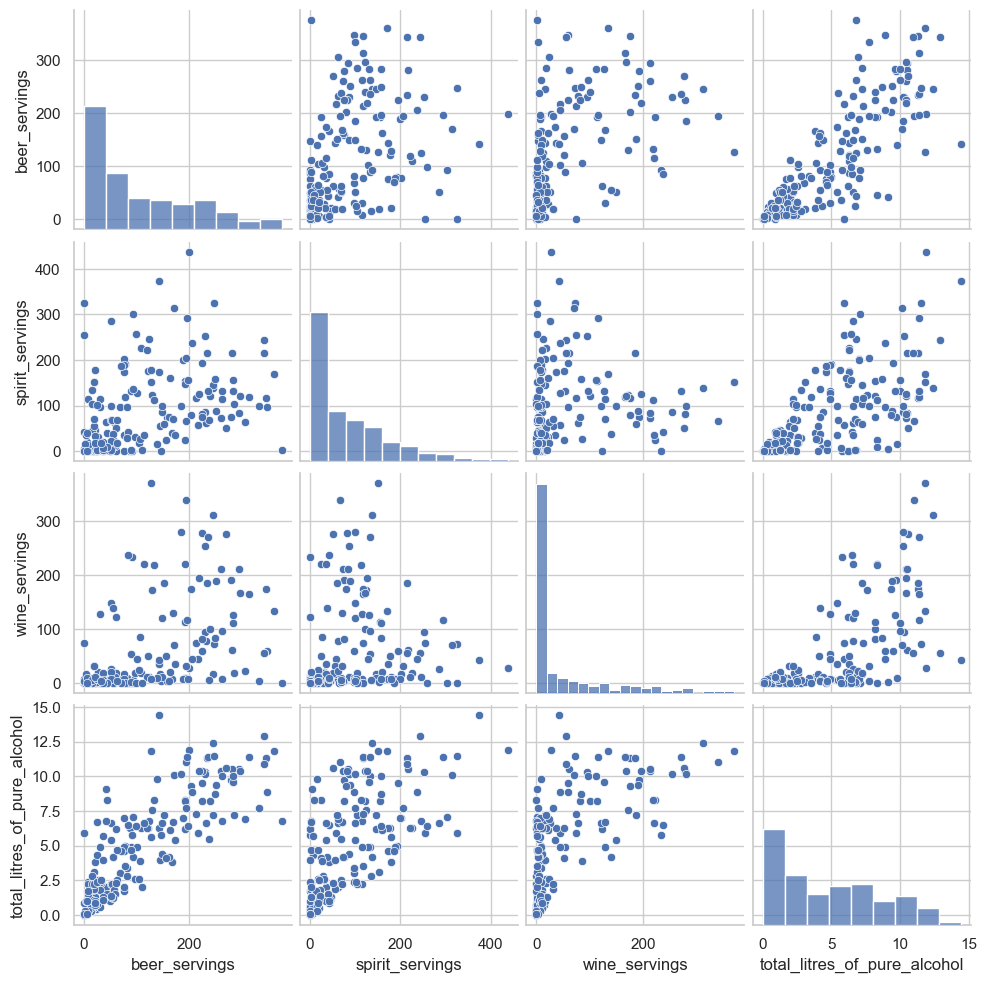

In [14]:
sns.set(style = "whitegrid")
sns.pairplot(drinks[cor_cols])

plt.show()

- total_litres_of_pure_alcohol 피처가 대체적으로 다른 모든 피처와 강한 상관관계가 있는 것으로 보임

- 특히 beer와의 상관성이 가장 높음

## 데이터 전처리

### continent 결측치 대체

In [15]:
drinks.isnull().sum()

country                          0
beer_servings                    0
spirit_servings                  0
wine_servings                    0
total_litres_of_pure_alcohol     0
continent                       23
dtype: int64

In [16]:
drinks["continent"].unique()

array(['AS', 'EU', 'AF', nan, 'SA', 'OC'], dtype=object)

In [17]:
drinks[drinks["continent"].isnull()]

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
5,Antigua & Barbuda,102,128,45,4.9,NaN
11,Bahamas,122,176,51,6.3,NaN
14,Barbados,143,173,36,6.3,NaN
17,Belize,263,114,8,6.8,NaN
32,Canada,240,122,100,8.2,NaN
41,Costa Rica,149,87,11,4.4,NaN
43,Cuba,93,137,5,4.2,NaN
50,Dominica,52,286,26,6.6,NaN
51,Dominican Republic,193,147,9,6.2,NaN
54,El Salvador,52,69,2,2.2,NaN


In [18]:
# 결측치를 NA로 대체
drinks["continent"] = drinks["continent"].fillna("NA")

In [19]:
drinks["continent"].value_counts()

continent
AF    53
EU    45
AS    44
NA    23
OC    16
SA    12
Name: count, dtype: int64

## 추가 데이터 탐색

### 각 대륙별 비율 확인

In [20]:
continents = drinks["continent"].value_counts()

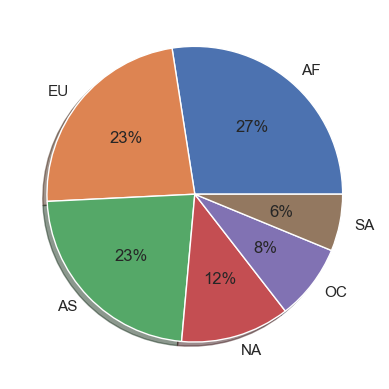

In [21]:
plt.pie(continents.values, labels = continents.index, autopct = "%.0f%%", shadow = True)

plt.show()

### 대륙별 spirit_servings의 통계 정보 확인

In [22]:
# 대륙별 spirit_servings의 평균, 최소, 최대, 합계 확인
stat = drinks.groupby("continent")["spirit_servings"].agg(["mean", "min", "max", "sum"])
stat

,mean,min,max,sum
continent,,,,
AF,16.339623,0,152,866
AS,60.840909,0,326,2677
EU,132.555556,0,373,5965
NA,165.739130,68,438,3812
OC,58.437500,0,254,935
SA,114.750000,25,302,1377


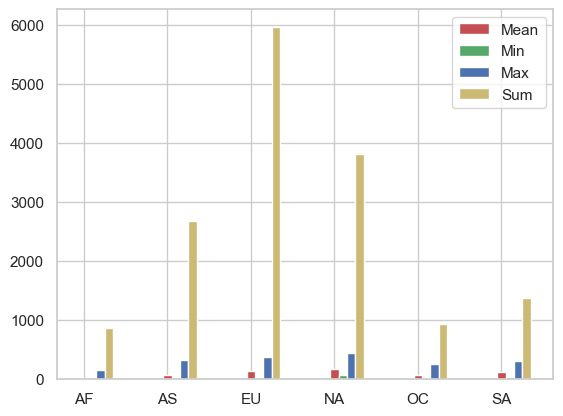

In [23]:
n_groups = len(stat)
idx = np.arange(n_groups)

rects1 = plt.bar(idx, stat["mean"], width = 0.1, color = "r", label = "Mean")
rects2 = plt.bar(idx + 0.1, stat["min"], width = 0.1, color = "g", label = "Min")
rects3 = plt.bar(idx + 0.2, stat["max"], width = 0.1, color = "b", label = "Max")
rects4 = plt.bar(idx + 0.3, stat["sum"], width = 0.1, color = "y", label = "Sum")

plt.xticks(idx, stat.index)
plt.legend()

plt.show()

### 전체 평균보다 더 많은 알코올을 섭취하는 대륙

In [24]:
alc_mean = drinks["total_litres_of_pure_alcohol"].mean()
alc_mean

np.float64(4.717098445595855)

In [25]:
con_mean = drinks.groupby("continent")["total_litres_of_pure_alcohol"].mean()
con_mean

continent
AF    3.007547
AS    2.170455
EU    8.617778
NA    5.995652
OC    3.381250
SA    6.308333
Name: total_litres_of_pure_alcohol, dtype: float64

In [26]:
con_mean[con_mean >= alc_mean]

continent
EU    8.617778
NA    5.995652
SA    6.308333
Name: total_litres_of_pure_alcohol, dtype: float64

In [27]:
# 전체 평균도 시각화해주기 위해서 대륙 리스트에 mean 추가
continents = con_mean.index.tolist()
continents.append("mean")
continents

['AF', 'AS', 'EU', 'NA', 'OC', 'SA', 'mean']

In [28]:
alc = con_mean.tolist()
alc.append(alc_mean)
alc

[3.0075471698113208,
 2.1704545454545454,
 8.617777777777778,
 5.995652173913044,
 3.38125,
 6.308333333333334,
 np.float64(4.717098445595855)]

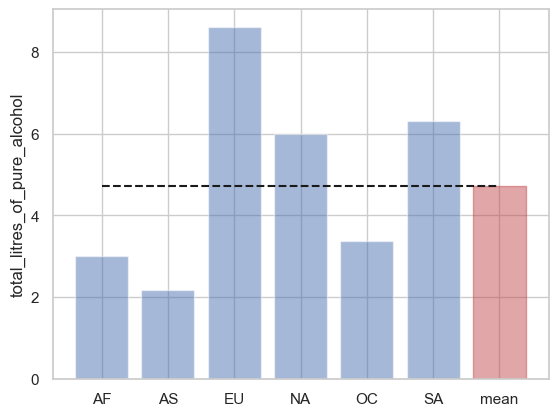

In [29]:
x_pos = np.arange(len(continents))

bar_list = plt.bar(x_pos, alc, alpha = 0.5)

# 마지막 바만 빨간색으로 변경
bar_list[-1].set_color("r")

# 평균선 그리기
plt.plot([0, len(continents) - 1], [alc_mean, alc_mean], "k--")

plt.xticks(x_pos, continents)
plt.ylabel("total_litres_of_pure_alcohol")

plt.show()

## 통계 분석

- 지금까지의 분석은 통찰을 발견하는데 있어서는 유용했지만 분석가의 주관에 따라 분석된 내용이기 때문에 타당성을 입증하기 어려움

- 타당성을 위해서는 통계적으로 검정하는 과정이 필요

- t검정
    - 두 집단 간 평균의 차이에 대한 검정
 
    - 모집단의 평균을 모를 때 현재의 데이터만으로 두 집단의 차이에 대해 검정 가능
 
    - 단, 두 집단의 데이터 개수가 비슷하고, 정규분포인 경우 신뢰도가 높음

### 아프리카와 유럽 간의 맥주 소비량 차이 검정

In [30]:
# 통계 모듈
from scipy import stats

In [31]:
af = drinks[drinks["continent"] == "AF"]
eu = drinks[drinks["continent"] == "EU"]

In [32]:
af.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
2,Algeria,25,0,14,0.7,AF
4,Angola,217,57,45,5.9,AF
18,Benin,34,4,13,1.1,AF
22,Botswana,173,35,35,5.4,AF
26,Burkina Faso,25,7,7,4.3,AF


In [33]:
eu.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
1,Albania,89,132,54,4.9,EU
3,Andorra,245,138,312,12.4,EU
7,Armenia,21,179,11,3.8,EU
9,Austria,279,75,191,9.7,EU
10,Azerbaijan,21,46,5,1.3,EU


In [34]:
t_result = stats.ttest_ind(af["beer_servings"], eu["beer_servings"], equal_var = True) # 두 집단의 분산이 같은 경우
t_result_diff = stats.ttest_ind(af["beer_servings"], eu["beer_servings"], equal_var = False) # 두 집단의 분산이 같은 경우

In [35]:
print(t_result)
print(t_result_diff)

TtestResult(statistic=np.float64(-7.267986335644365), pvalue=np.float64(9.719556422442453e-11), df=np.float64(96.0))
TtestResult(statistic=np.float64(-7.143520192189803), pvalue=np.float64(2.9837787864303205e-10), df=np.float64(84.40013075489844))


- t-statistic(t-test의 검정 통계량)
    - 그 자체로는 아무 의미 없으며 p-value와 함께 해석해야 함
 
    - 귀무가설과의 차이를 의미
 
- p-value(유의확률)
    - 가설이 얼마나 믿을만한 것인지를 나타내는 지표
 
    - 데이터를 새로 샘플링 했을 때 귀무가설이 맞다는 전제 하에 현재 나온 통계값 이상이 나올 확률
        - 즉, p-value가 낮으면 귀무가설이 일어날 확률이 너무 낮기 때문에 귀무가설을 기각하게 됨
            - 보통 그 기준은 0.05나 0.01을 기준으로 함
         
- 귀무가설
    - 처음부터 버릴 것을 예상하는 가설
 
    - 가설이 맞지 않다는 것을 증명하기 위해 수립하는 가설
 
    - 반대되는 가설을 대립가설이라고 부르며, 귀무가설이 거짓인 경우에 대안으로 참이 되는 가설

- p-value 해석 순서
  1. 귀무가설이 참이라고 가정
        - 그래, 일단 네 말이 맞자도 치자.
  2. 위의 가정 하에서, "우리가 실제로 관측한 값(또는 더 극단적인 값)이 나올 확률"을 계산 <- p-value
        - 근데 네 말이 맞다면, 지금 나온 결과는 너무 보기 힘든 결과 아니야? 이건 말이 안되지 않아?
  3. 이 확률이 낮다면 귀무가설 기각
        - 그니까 니 말이 틀렸겠지?

#### 분석 내용

- t-test의 귀무가설 : "두 집단의 평균이 같다"

- p-value가 0.05 미만으로 나타나 귀무가설이 기각

- 따라서 "아프리카와 유럽 대륙 간의 맥주 소비량 차이"는 통계적으로 유의미하다
    - 두 집단의 평균은 다르다

- 피어슨 상관분석
    - H0 : 두 변수는 상관관계가 없다
    - H1 : 두 변수는 상관관계가 있다

In [38]:
stats.pearsonr(drinks["beer_servings"], drinks["total_litres_of_pure_alcohol"])

PearsonRResult(statistic=np.float64(0.8358386279352703), pvalue=np.float64(1.236915790998306e-51))

In [39]:
stats.pearsonr(drinks["wine_servings"], drinks["spirit_servings"])

PearsonRResult(statistic=np.float64(0.1947970470098455), pvalue=np.float64(0.006633935450032313))